In [50]:
from FusionModel.util import plot_data_flat, plot_multi_flat


In [51]:
# Add the directories of necessary packages to the Python path
import numpy as np
import torch as pt
import nibabel as nb
import nitools as nt
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import Functional_Fusion.dataset as ds
import IndividualParcellation.scripts.paths as paths
from IndividualParcellation.scripts.paths import base_dir
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.full_model as fm
from FusionModel.util import plot_data_flat, plot_multi_flat
import pandas as pd
import seaborn as sb
import warnings
# Ignore RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)

pt.set_default_tensor_type(pt.cuda.FloatTensor
                           if pt.cuda.is_available() else
                           pt.FloatTensor)



In [52]:
# Settings
symmetric = True # Whether to get a symmetric or asymmetric parcellation
if symmetric:
    sym_type = 'sym'

space, _ = am.get_atlas('MNISymC2')
if space.name == 'MNISymC2':
    space_folder = 'tpl-MNI152NLin2009cSymC'

data_dir = paths.set_fusion_dir()
figure_dir = paths.set_figure_dir()

In [53]:
atlas_dir = paths.set_atlas_dir()
atlas = 'NettekovenSym32'
model_name = f'/{space_folder}/atl-{atlas}_space-{space_folder.split("tpl-")[1]}_probseg.nii'
_, cmap, labels = nt.read_lut(f'{atlas_dir}/{space_folder}/atl-{atlas}.lut')
U = space.read_data(atlas_dir + model_name)
U = U.T
ar_model = ar.build_arrangement_model(U, prior_type='prob', sym_type=sym_type, atlas=space)

/Users/callithrix/code/Python/HierarchBayesParcel/arrangements.py:1943: UserWarning: The marginal probability has 18207 voxels zero values - adding small value to avoid -inf
  warnings.warn(f'The marginal probability has {zero_voxl} voxels'


## Load MDTB Rest subject list

In [54]:
T = pd.read_csv(f'{data_dir}/MDTB/participants.tsv', delimiter='\t')
participants = T.participant_id
rest_subjects = participants[T['ses-rest'] == 1].tolist()

## Load MDTB Task data

In [48]:
# Step 4b.1: Load the data into 3d tensor
data_task, info_task, tds = ds.get_dataset(data_dir, 'MDTB', atlas=space.name, subj=rest_subjects)

# Step 4b.2: Prepare the data into the right format
tdata_task, cond_v_task, part_v_task, sub_ind = fm.prep_datasets(data_task, info_task.sess,
                                                  info_task['cond_num_uni'].values,
                                                  info_task['half'].values,
                                                  join_sess=False,
                                                  join_sess_part=False)

In [49]:
indiv_par_task, _, model_task = fm.get_indiv_parcellation(ar_model, space, tdata_task, cond_v_task, part_v_task, sub_ind, Vs=None, sym_type = sym_type)

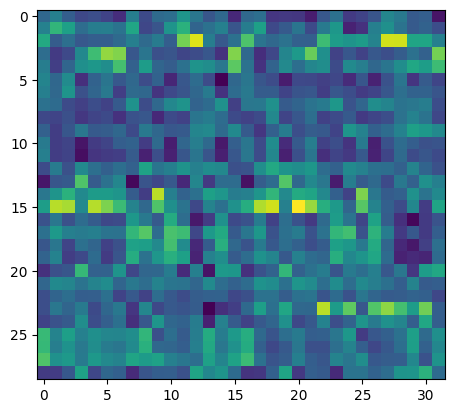

In [8]:
plt.imshow(model_task.emissions[0].V)

([<matplotlib.axis.YTick at 0x15bbb5bb0>,
 [Text(0, 0, 'sub-02'),
  Text(0, 1, 'sub-03'),
  Text(0, 2, 'sub-06'),
  Text(0, 3, 'sub-08'),
  Text(0, 4, 'sub-10'),
  Text(0, 5, 'sub-12'),
  Text(0, 6, 'sub-14'),
  Text(0, 7, 'sub-18'),
  Text(0, 8, 'sub-20'),
  Text(0, 9, 'sub-22'),
  Text(0, 10, 'sub-24'),
  Text(0, 11, 'sub-25'),
  Text(0, 12, 'sub-26'),
  Text(0, 13, 'sub-27'),
  Text(0, 14, 'sub-28'),
  Text(0, 15, 'sub-30'),
  Text(0, 16, 'sub-31')])

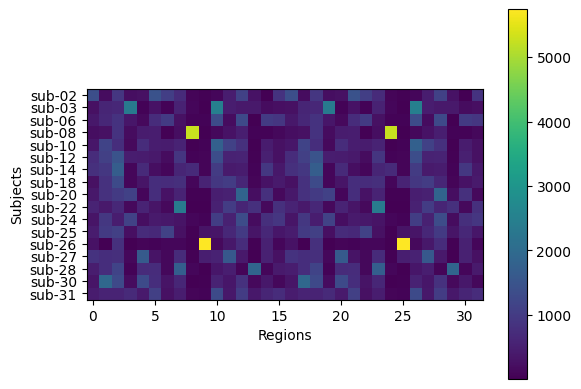

In [9]:
plt.imshow(indiv_par_task.sum(axis=2))
plt.xlabel('Regions')
plt.ylabel('Subjects')
plt.colorbar()
# set ytick labels
plt.yticks(np.arange(len(rest_subjects)), rest_subjects)


## Resting-state data

### Type: Net67Run

In [55]:
# Step 4b.1: Load the data into 3d tensor
data67, info67, tds = ds.get_dataset(data_dir, 'MDTB', atlas=space.name, sess='ses-rest', type='Net67Run', subj=rest_subjects)

# Step 4b.2: Prepare the data into the right format
tdata67, cond_v67, part_v67, sub_ind_v67 = fm.prep_datasets(data67, info67.sess,
                                                  info67['net_id'].values,
                                                  info67['half'].values,
                                                  join_sess=False,
                                                  join_sess_part=False)

Text(0, 0.5, 'Subjects')

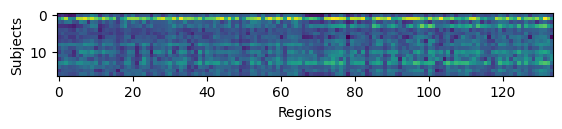

In [59]:
plt.imshow(np.nanmean(tdata67, axis=3).squeeze())
plt.xlabel('Regions')
plt.ylabel('Subjects')

In [12]:
indiv_par_rest_net67, _, model_rest67 = fm.get_indiv_parcellation(ar_model, space, tdata67, cond_v67, part_v67, sub_ind_v67, Vs=None, sym_type = sym_type)

/Users/callithrix/code/Python/HierarchBayesParcel/full_model.py:352: UserWarning: Likelihood decreased - terminating on iteration 26
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


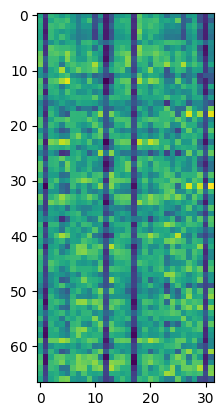

In [13]:
plt.imshow(model_rest67.emissions[0].V)

([<matplotlib.axis.XTick at 0x15b645190>,
 [Text(1, 0, 'M1L'),
  Text(5, 0, 'A1L'),
  Text(9, 0, 'D2L'),
  Text(13, 0, 'S2L'),
  Text(17, 0, 'M1R'),
  Text(21, 0, 'A1R'),
  Text(25, 0, 'D2R'),
  Text(29, 0, 'S2R')])

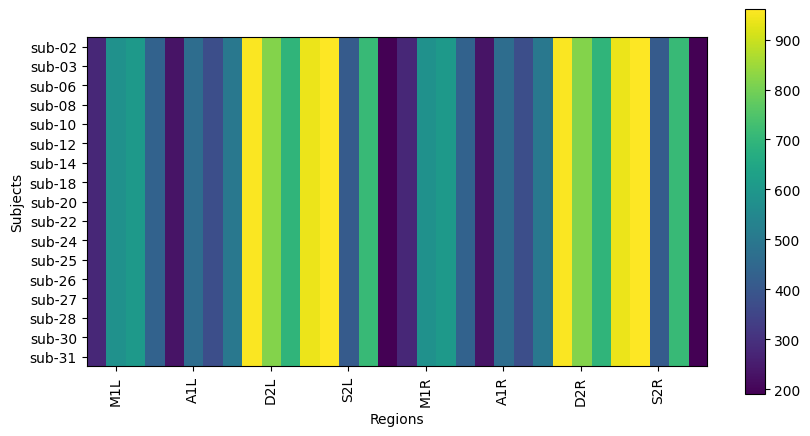

In [16]:
plt.figure(figsize=(10, 5))
plt.imshow(indiv_par_rest_net67.sum(axis=2))
plt.xlabel('Regions')
plt.ylabel('Subjects')
plt.colorbar()
# set ytick labels
plt.yticks(np.arange(len(rest_subjects)), rest_subjects)
plt.xticks(np.arange(32)[1::4], labels[1::4], rotation=90)

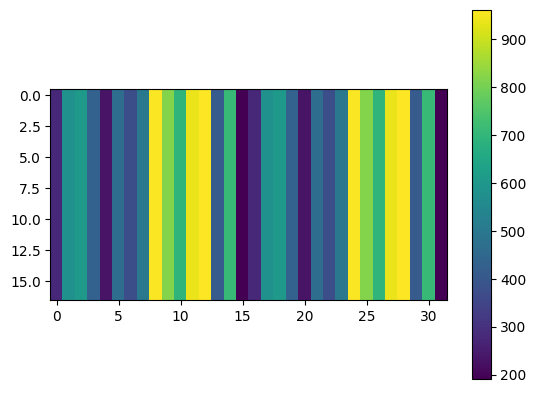

In [19]:
plt.imshow(indiv_par_rest_net67.sum(axis=2))
plt.colorbar()
plt.savefig(f'{figure_dir}/subject_region_influence_rest.png', dpi=300, bbox_inches='tight')

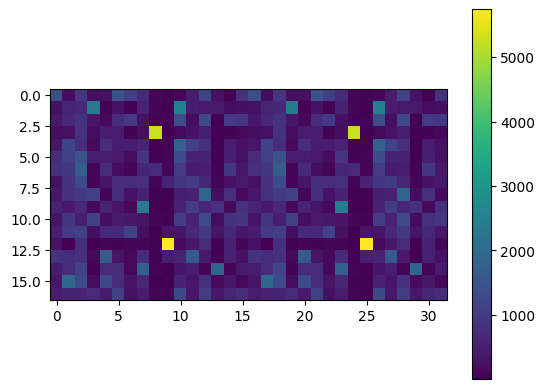

In [20]:
plt.imshow(indiv_par_task.sum(axis=2))
plt.colorbar()
plt.savefig(f'{figure_dir}/subject_region_influence_task.png', dpi=300, bbox_inches='tight')

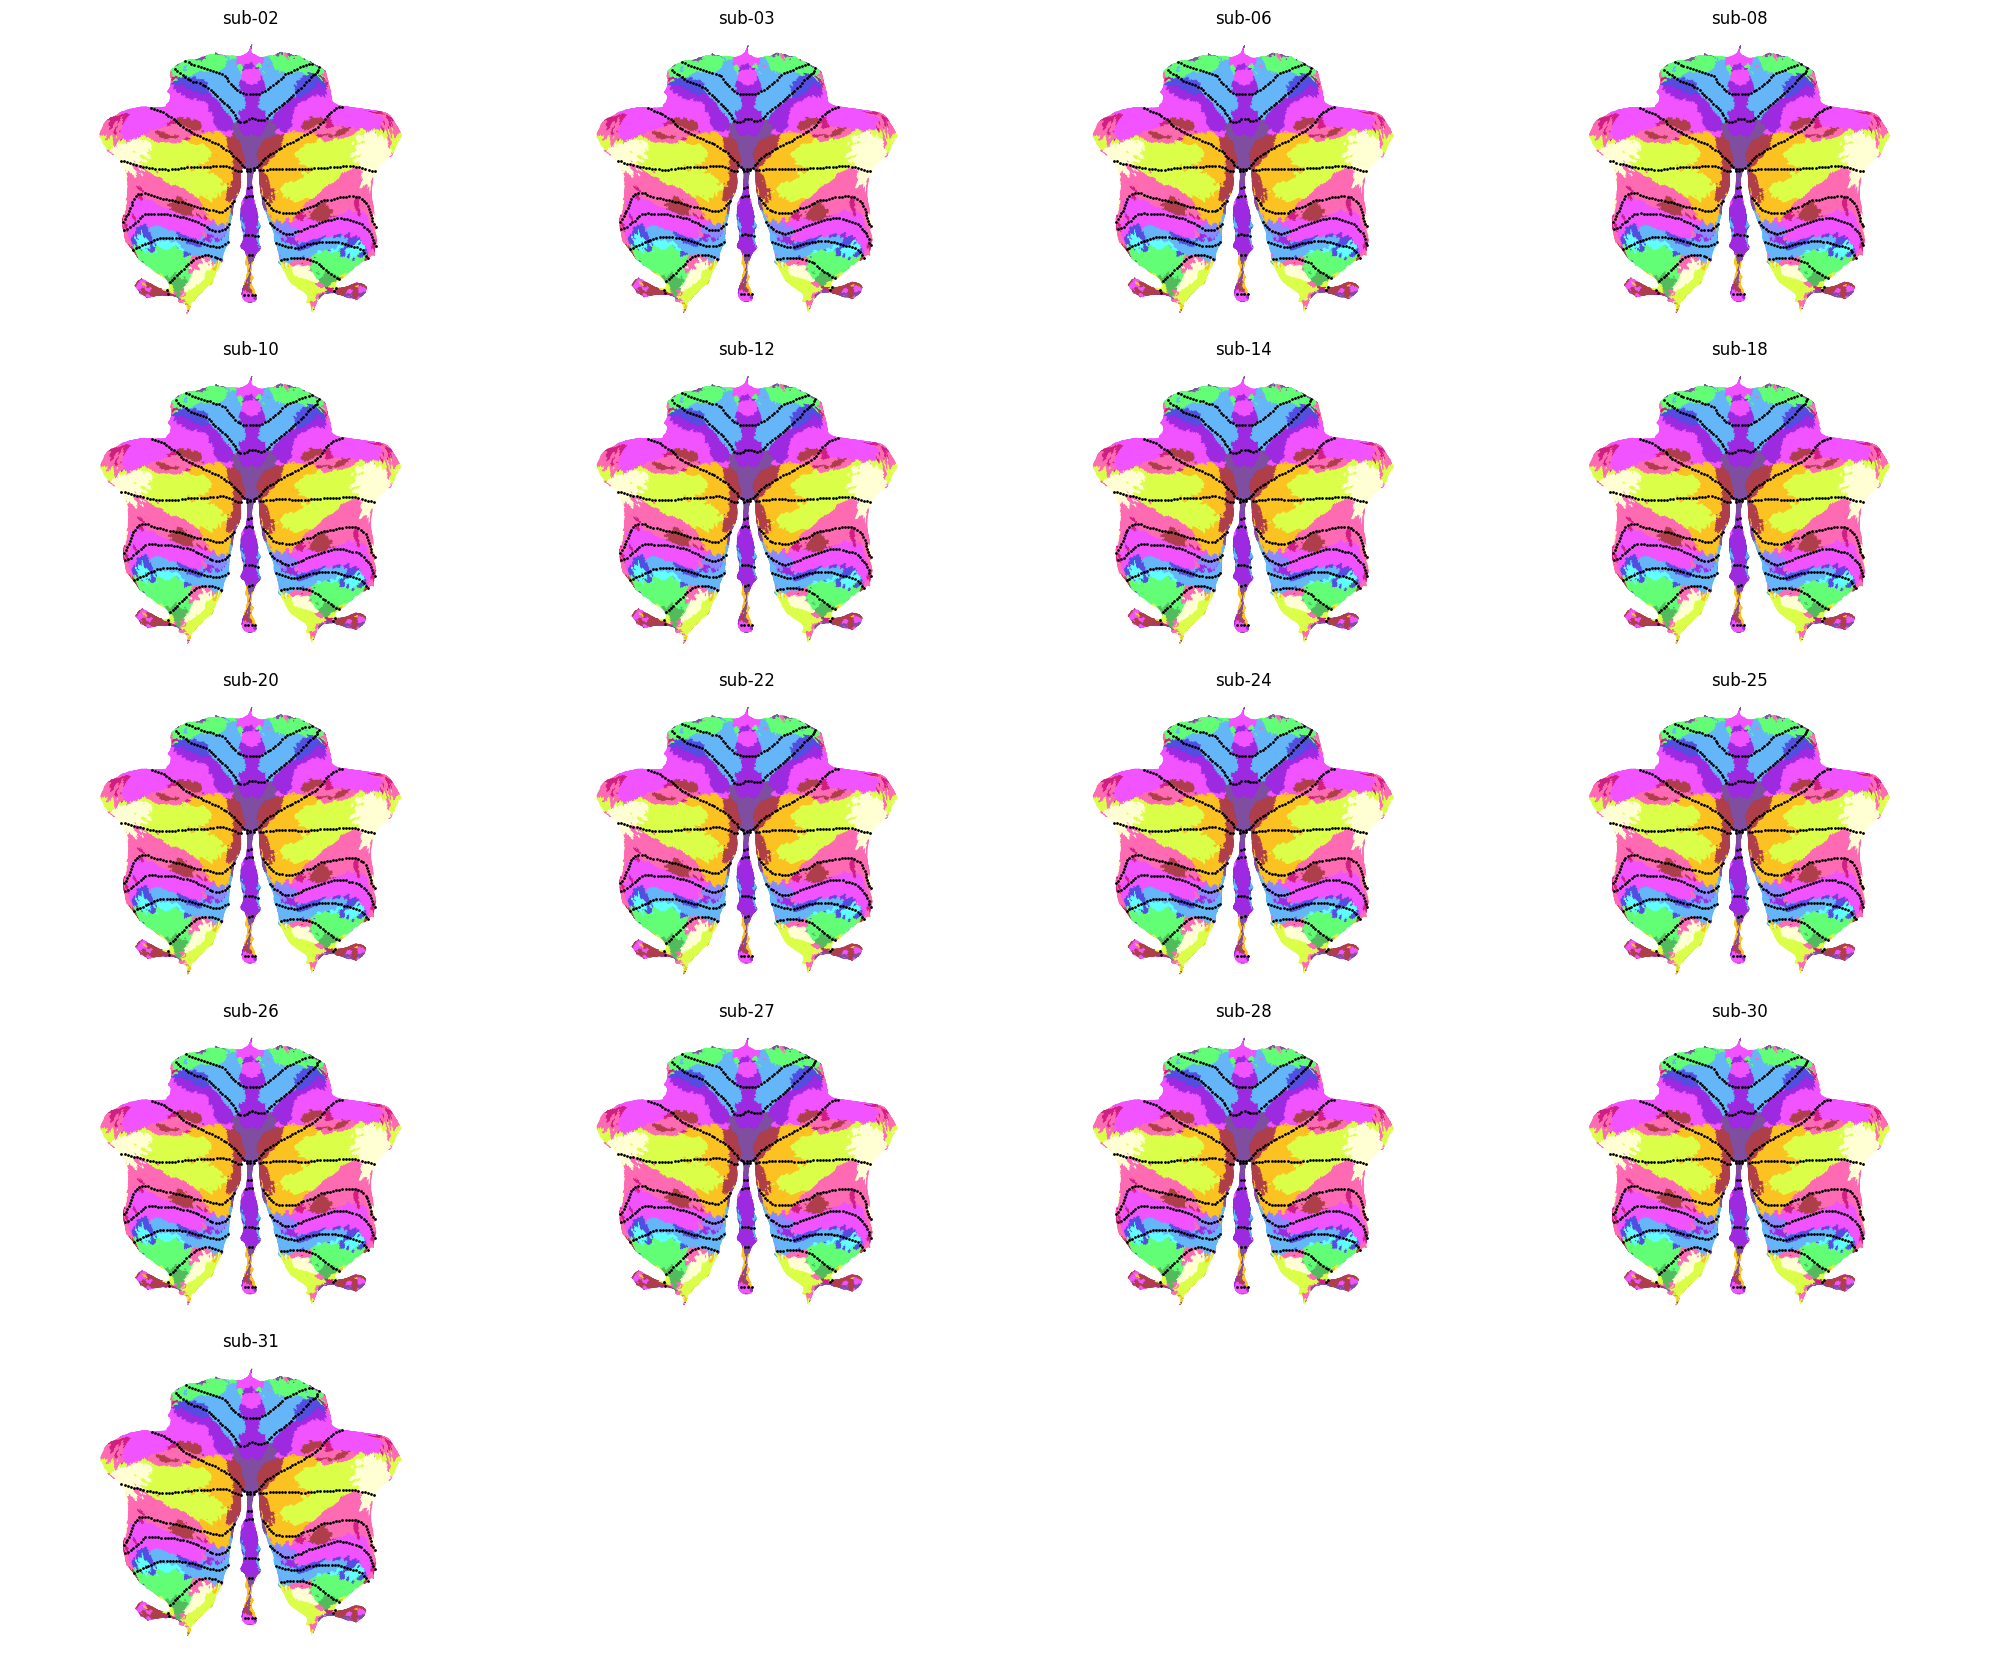

In [23]:
plt.figure(figsize=(20,20))
plot_multi_flat(indiv_par_rest_net67.cpu().numpy(), atlas=space.name, grid=(6, 4),
                cmap=cmap, dtype='prob',
                titles=rest_subjects)
plt.savefig(f'{figure_dir}/indiv_par_rest_net67_newEm.png', dpi=300, bbox_inches='tight')

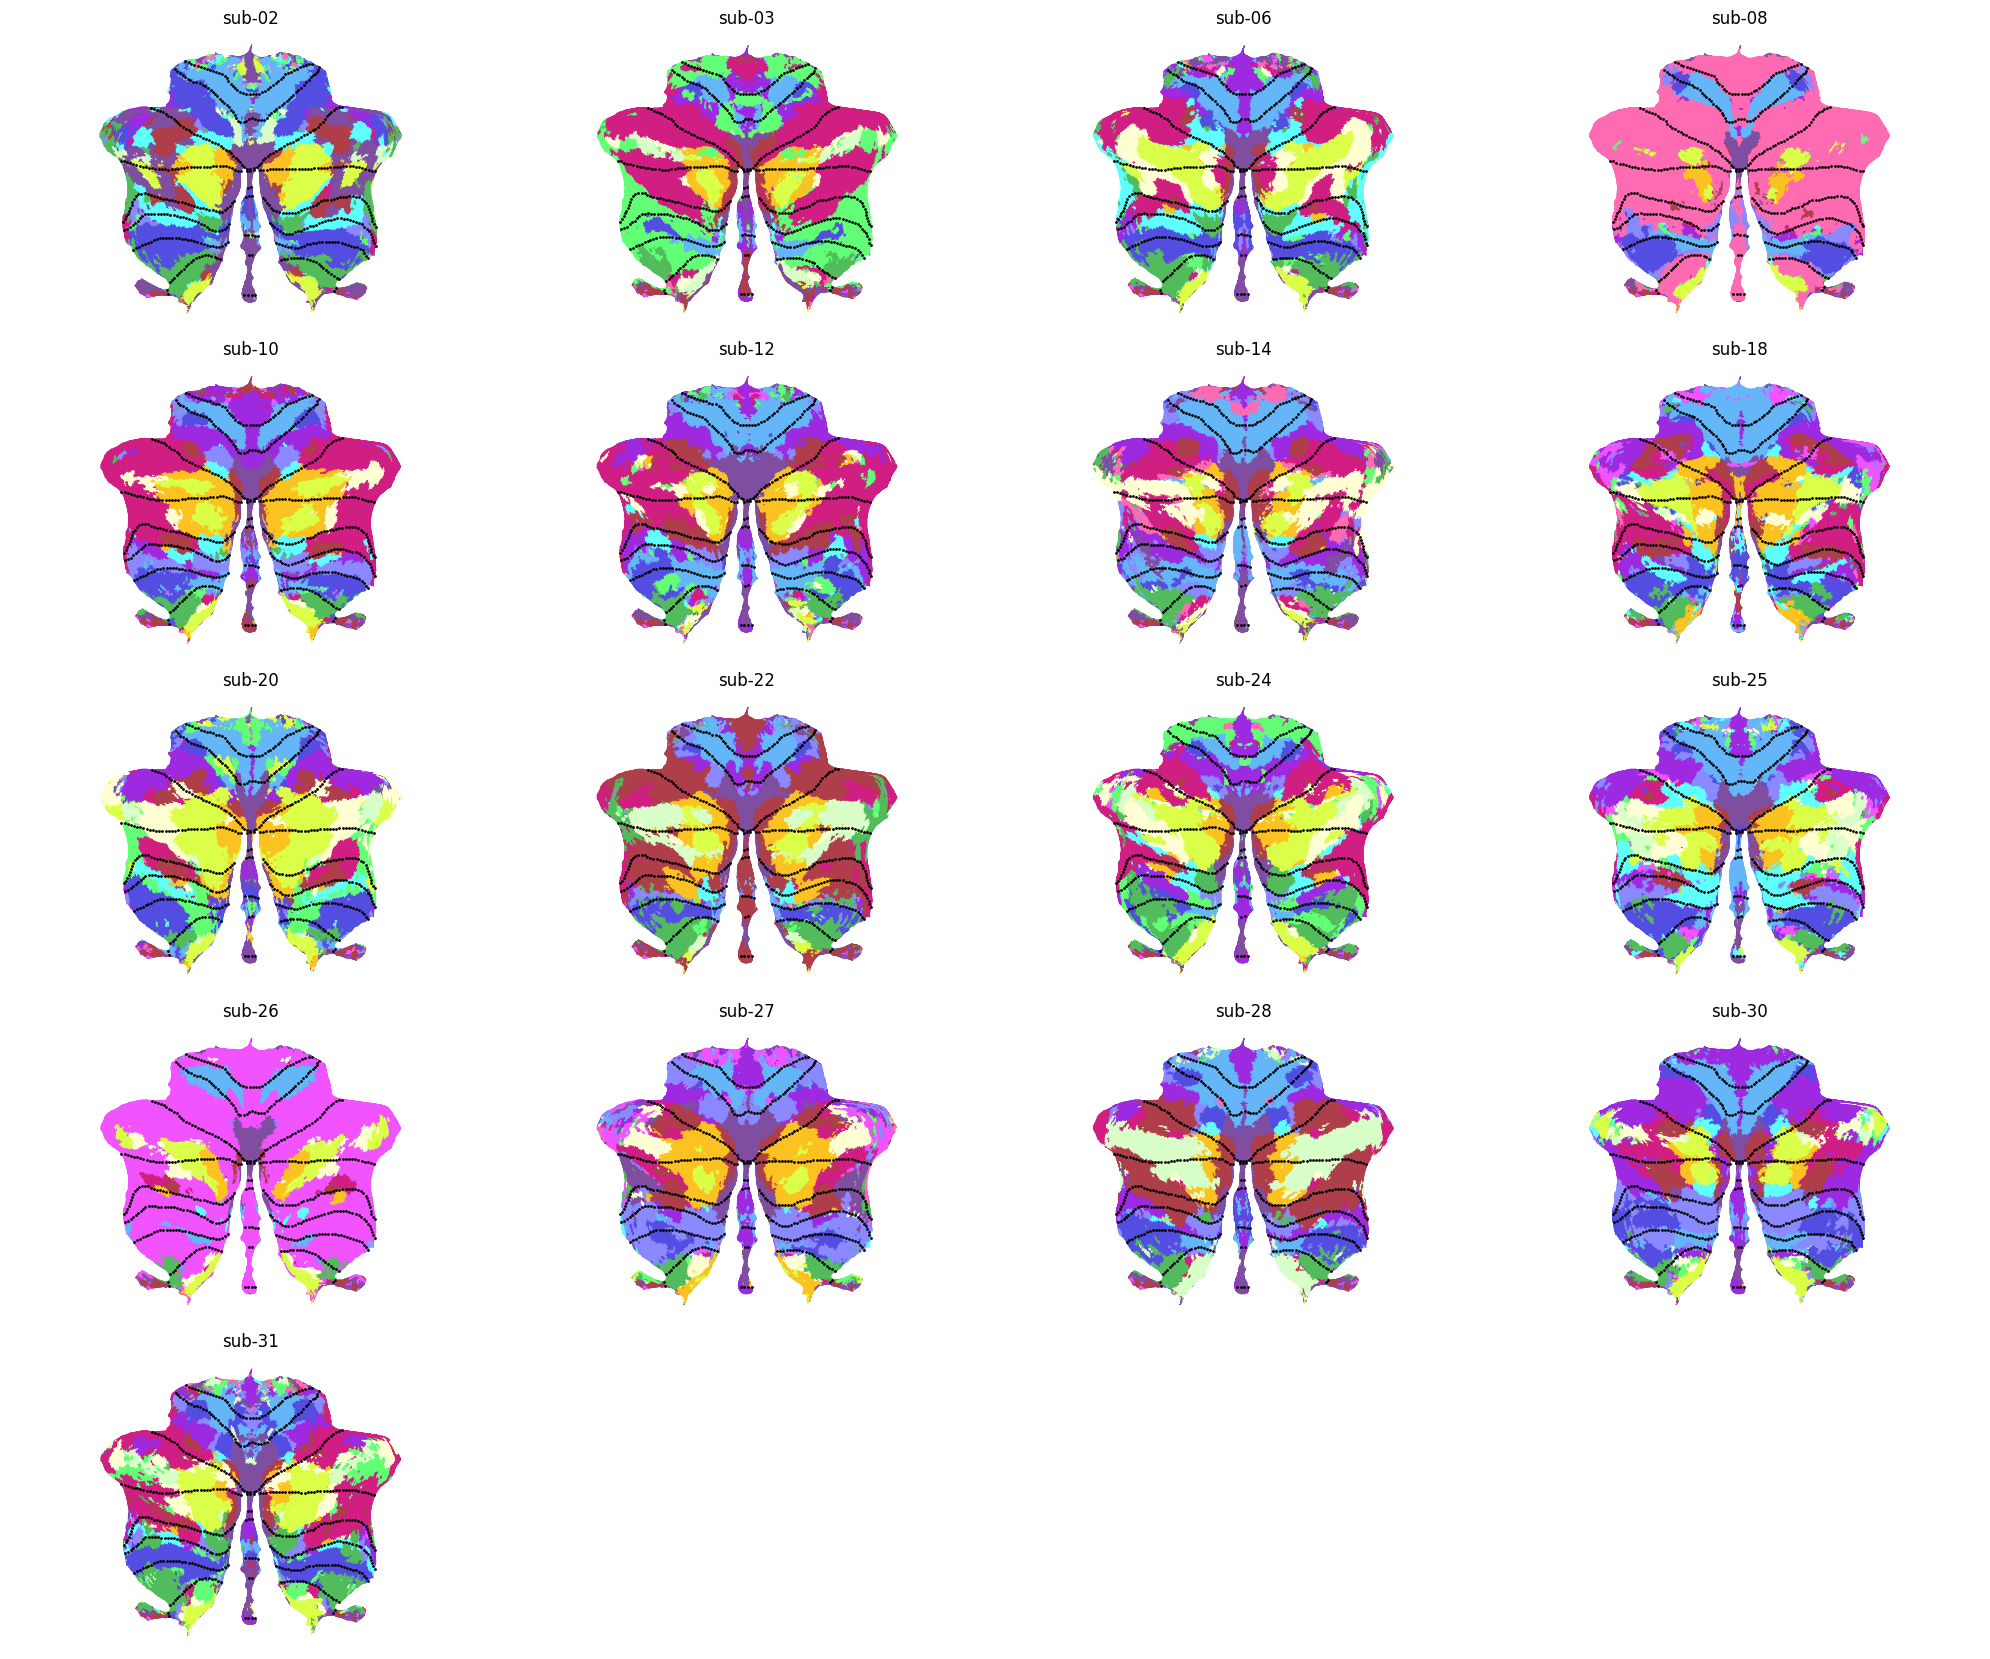

In [24]:
plt.figure(figsize=(20,20))
plot_multi_flat(indiv_par_task.cpu().numpy()[:6*4,:,:], atlas=space.name, grid=(6, 4),
                titles=rest_subjects,
                cmap=cmap, dtype='prob')
plt.savefig(f'{figure_dir}/indiv_par_task_newEm.png', dpi=300, bbox_inches='tight')